# Section 1: Notebook Setup & Imports

This section initializes the environment, sets up path resolution, imports libraries for modeling and evaluation, and configures the random seed for reproducibility. We also verify CUDA availability for XGBoost.

In [1]:
import os
import sys
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import torch
import xgboost as xgb
from xgboost import XGBRegressor

def find_project_root():
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for cand in candidates:
        if (cand / "data").exists() and (cand / "d_models").exists():
            return cand
    raise FileNotFoundError("Could not locate repo root containing 'data'")

PROJECT_ROOT = find_project_root()
print(f"Project root found: {PROJECT_ROOT}")

# Append project root to sys.path
sys_path_root = str(PROJECT_ROOT)
if sys_path_root not in sys.path:
    sys.path.append(sys_path_root)

# Import metrics dashboard from project utilities
try:
    from u_dashboard.dashboard import metrics_dashboard
    print("Imported dashboard from u_dashboard.dashboard")
except ImportError:
    try:
        from Models.Utils.dashboard import metrics_dashboard
        print("Imported dashboard from Models.Utils")
    except ImportError:
        from Utils.dashboard import metrics_dashboard
        print("Imported dashboard from local Utils")

import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print(f"Random seed set to {SEED}")

# Setup plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Verify CUDA/GPU availability for XGBoost
try:
    dummy = xgb.XGBRegressor(n_estimators=1, device="cuda")
    dummy.fit(np.array([[1.0]]), np.array([1.0]))
    XGB_DEVICE = "cuda"
    print("XGBoost CUDA support verified and enabled.")
except Exception as e:
    XGB_DEVICE = "cpu"
    print(f"XGBoost CUDA test failed ({e}). Falling back to CPU.")

print("Setup complete. Using device:", XGB_DEVICE)

Project root found: C:\Users\pan\Documents\GitHub\MDR-Project
Imported dashboard from u_dashboard.dashboard
Random seed set to 42


XGBoost CUDA support verified and enabled.
Setup complete. Using device: cuda


# Section 2: Data Loading & Preprocessing

This section loads the train, validation, and test splits for the `derived_8.1_pos` dataset. We concatenate the train and validation sets to form the `trainval` split for model training. We parse dates, extract the `year` and `month` features, and compute the temporal recency weights (Drift) using $\beta = 0.2$ as established in the `v25` baseline.

In [2]:
# Define path configurations
TRAIN_PATH = PROJECT_ROOT / "data/splits/derived_8.2/train.csv"
VAL_PATH = PROJECT_ROOT / "data/splits/derived_8.2/val.csv"
TEST_PATH = PROJECT_ROOT / "data/splits/derived_8.2/test.csv"

# Load dataset splits
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Dataset splits loaded:")
print(f"  train: {train_df.shape}")
print(f"  val:   {val_df.shape}")
print(f"  test:  {test_df.shape}")

# Parse date, extract month and year
for df in [train_df, val_df, test_df]:
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month.astype(int)
    df["year"] = df["date"].dt.year.astype(float)

# Concatenate train and val for training+validation
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
print(f"  trainval (concatenated): {trainval_df.shape}")

# Compute temporal recency weights (Drift) with beta = 0.2
years_tv = trainval_df["year"]
max_year = years_tv.max()
beta = 0.2
w_trainval = np.exp(beta * (years_tv - max_year))
w_trainval = w_trainval / w_trainval.mean()

print(f"\nTemporal Recency Weighting (Drift) initialized with beta={beta}:")
print(f"  Min weight: {w_trainval.min():.4f}")
print(f"  Max weight: {w_trainval.max():.4f}")


Dataset splits loaded:
  train: (15704, 499)
  val:   (7149, 499)
  test:  (8902, 499)
  trainval (concatenated): (22853, 500)

Temporal Recency Weighting (Drift) initialized with beta=0.2:
  Min weight: 0.5801
  Max weight: 1.5768


# Section 3: Feature Sets Configuration

This section loads the two feature sets to be compared:
- **Model V1**: The 40 features from `OVERALL_SELECTED_FEATURES_V1` defined in the `derived_8.2` split metadata.
- **Model V2**: The 40 features from `OVERALL_SELECTED_FEATURES_V2` defined in the `derived_8.2` split metadata.


In [3]:
# Import Feature Sets from dataset_metadata for derived_8.2
import importlib.util
metadata_path = PROJECT_ROOT / "data/splits/derived_8.2/dataset_metadata.py"
spec = importlib.util.spec_from_file_location("dataset_metadata", metadata_path)
dataset_metadata = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dataset_metadata)

FEATURE_SET_V1 = dataset_metadata.OVERALL_SELECTED_FEATURES_V1
FEATURE_SET_V2 = dataset_metadata.OVERALL_SELECTED_FEATURES_V2
TARGET_COL = "soil_moisture_5cm"

print(f"Feature Set V1 count: {len(FEATURE_SET_V1)}")
print(f"Feature Set V2 count: {len(FEATURE_SET_V2)}")


Feature Set V1 count: 40
Feature Set V2 count: 40


# Section 4: Evaluation Utilities & Parameters

We define the metrics calculation utility and target variables. We also set up the hyperparameters for the XGBoost model configurations matching `MDR-v25.ipynb`:
- `XGB_PARAMS_NO_W`: The non-weighted baseline using `reg:absoluteerror`.
- `XGB_PARAMS_W`: The weighted baseline using `reg:pseudohubererror`.

In [4]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    err = y_true - y_pred
    ae = np.abs(err)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    ubrmse = np.sqrt(np.mean(((y_true - np.mean(y_true)) - (y_pred - np.mean(y_pred))) ** 2))
    bias = np.mean(err)
    med_ae = np.median(ae)
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        pearson = float("nan")
    else:
        pearson = np.corrcoef(y_true, y_pred)[0, 1]
    return {
        "R2": r2, "RMSE": rmse, "ubRMSE": ubrmse, "Bias": bias, "MAE": mae, "Med|Err|": med_ae, "Pearson": pearson
    }

def print_metrics(metrics, title):
    print(f"\n===== {title} =====")
    for k, v in metrics.items():
        print(f"{k:10s}: {v:.5f}")

XGB_PARAMS_NO_W = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
    device=XGB_DEVICE
)

XGB_PARAMS_W = dict(
    objective="reg:pseudohubererror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
    device=XGB_DEVICE
)

# Section 5: Model V1 Evaluation (40 Features from OVERALL_SELECTED_FEATURES_V1)

We train and evaluate two global XGBoost models using Feature Set V1 (40 features):
1. **Model V1 (No Weights)**: Trained with `reg:absoluteerror` objective and no sample weighting.
2. **Model V1 (Weighted)**: Trained with `reg:pseudohubererror` objective and temporal recency weights ($\beta=0.2$).


In [5]:
y_trainval = np.asarray(trainval_df[TARGET_COL]).ravel()
y_test = np.asarray(test_df[TARGET_COL]).ravel()

# 1. Non-weighted model
print("Training Model V1 (40 features, No Weights)...")
xgb_v1_no_w = XGBRegressor(**XGB_PARAMS_NO_W)
xgb_v1_no_w.fit(trainval_df[FEATURE_SET_V1], y_trainval, verbose=0)
pred_v1_no_w = np.asarray(xgb_v1_no_w.predict(test_df[FEATURE_SET_V1])).ravel()
metrics_v1_no_w = compute_metrics(y_test, pred_v1_no_w)
print_metrics(metrics_v1_no_w, "MODEL V1 (40 FEAT, NO WEIGHTS) METRICS")

# 2. Weighted model
print("\nTraining Model V1 (40 features, Weighted)...")
xgb_v1_w = XGBRegressor(**XGB_PARAMS_W)
xgb_v1_w.fit(trainval_df[FEATURE_SET_V1], y_trainval, sample_weight=w_trainval, verbose=0)
pred_v1_w = np.asarray(xgb_v1_w.predict(test_df[FEATURE_SET_V1])).ravel()
metrics_v1_w = compute_metrics(y_test, pred_v1_w)
print_metrics(metrics_v1_w, "MODEL V1 (40 FEAT, WEIGHTED) METRICS")


Training Model V1 (40 features, No Weights)...



===== MODEL V1 (40 FEAT, NO WEIGHTS) METRICS =====
R2        : 0.60910
RMSE      : 0.06584
ubRMSE    : 0.06447
Bias      : -0.01333
MAE       : 0.04836
Med|Err|  : 0.03581
Pearson   : 0.79835

Training Model V1 (40 features, Weighted)...



===== MODEL V1 (40 FEAT, WEIGHTED) METRICS =====
R2        : 0.62631
RMSE      : 0.06437
ubRMSE    : 0.06303
Bias      : -0.01306
MAE       : 0.04788
Med|Err|  : 0.03691
Pearson   : 0.80842


# Section 6: Model V2 Evaluation (40 Features from OVERALL_SELECTED_FEATURES_V2)

We train and evaluate two global XGBoost models using Feature Set V2 (40 features):
1. **Model V2 (No Weights)**: Trained with `reg:absoluteerror` objective and no sample weighting.
2. **Model V2 (Weighted)**: Trained with `reg:pseudohubererror` objective and temporal recency weights ($\beta=0.2$).


In [6]:
# 1. Non-weighted model
print("Training Model V2 (40 features, No Weights)...")
xgb_v2_no_w = XGBRegressor(**XGB_PARAMS_NO_W)
xgb_v2_no_w.fit(trainval_df[FEATURE_SET_V2], y_trainval, verbose=0)
pred_v2_no_w = np.asarray(xgb_v2_no_w.predict(test_df[FEATURE_SET_V2])).ravel()
metrics_v2_no_w = compute_metrics(y_test, pred_v2_no_w)
print_metrics(metrics_v2_no_w, "MODEL V2 (40 FEAT, NO WEIGHTS) METRICS")

# 2. Weighted model
print("\nTraining Model V2 (40 features, Weighted)...")
xgb_v2_w = XGBRegressor(**XGB_PARAMS_W)
xgb_v2_w.fit(trainval_df[FEATURE_SET_V2], y_trainval, sample_weight=w_trainval, verbose=0)
pred_v2_w = np.asarray(xgb_v2_w.predict(test_df[FEATURE_SET_V2])).ravel()
metrics_v2_w = compute_metrics(y_test, pred_v2_w)
print_metrics(metrics_v2_w, "MODEL V2 (40 FEAT, WEIGHTED) METRICS")


Training Model V2 (40 features, No Weights)...



===== MODEL V2 (40 FEAT, NO WEIGHTS) METRICS =====
R2        : 0.63471
RMSE      : 0.06364
ubRMSE    : 0.06004
Bias      : -0.02111
MAE       : 0.04839
Med|Err|  : 0.03746
Pearson   : 0.82517

Training Model V2 (40 features, Weighted)...



===== MODEL V2 (40 FEAT, WEIGHTED) METRICS =====
R2        : 0.64263
RMSE      : 0.06295
ubRMSE    : 0.05952
Bias      : -0.02051
MAE       : 0.04736
Med|Err|  : 0.03586
Pearson   : 0.83024


# Section 7: Comparative Summary & Visualization

We print the summary metrics table comparing the four configurations and generate residual scatter plots.


===== COMPARATIVE PERFORMANCE SUMMARY =====
                     Configuration     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson
Model V1 (40 Features, No Weights) 0.6091 0.0658 0.0645 -0.0133 0.0484   0.0358  0.7984
  Model V1 (40 Features, Weighted) 0.6263 0.0644 0.0630 -0.0131 0.0479   0.0369  0.8084
Model V2 (40 Features, No Weights) 0.6347 0.0636 0.0600 -0.0211 0.0484   0.0375  0.8252
  Model V2 (40 Features, Weighted) 0.6426 0.0629 0.0595 -0.0205 0.0474   0.0359  0.8302


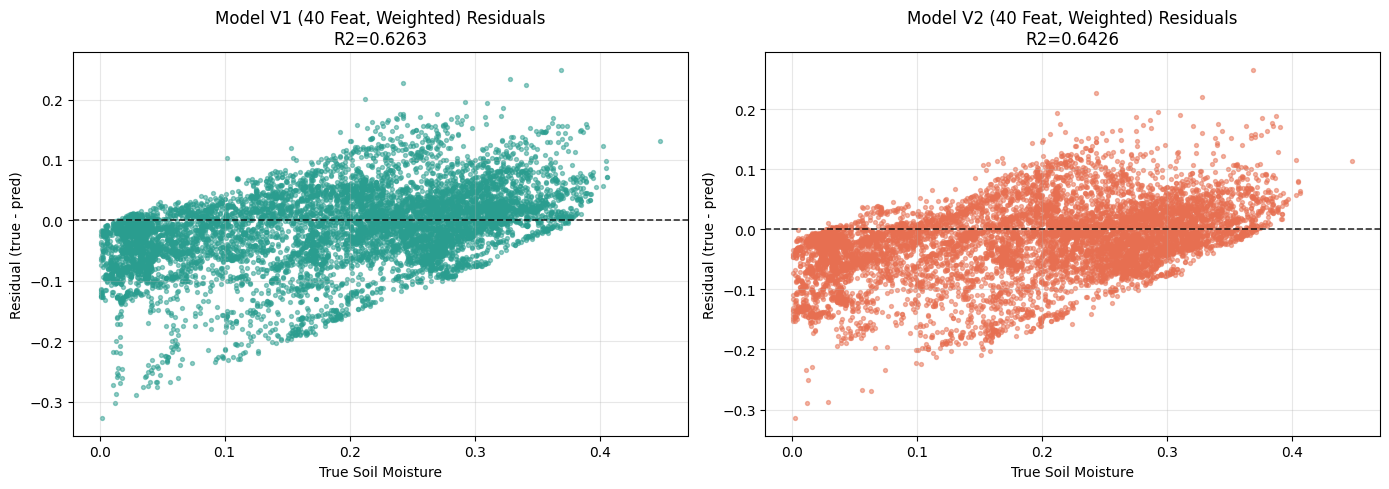

In [7]:
metrics_summary_data = {
    "Configuration": [
        "Model V1 (40 Features, No Weights)",
        "Model V1 (40 Features, Weighted)",
        "Model V2 (40 Features, No Weights)",
        "Model V2 (40 Features, Weighted)"
    ],
    "R2": [
        metrics_v1_no_w["R2"],
        metrics_v1_w["R2"],
        metrics_v2_no_w["R2"],
        metrics_v2_w["R2"]
    ],
    "RMSE": [
        metrics_v1_no_w["RMSE"],
        metrics_v1_w["RMSE"],
        metrics_v2_no_w["RMSE"],
        metrics_v2_w["RMSE"]
    ],
    "ubRMSE": [
        metrics_v1_no_w["ubRMSE"],
        metrics_v1_w["ubRMSE"],
        metrics_v2_no_w["ubRMSE"],
        metrics_v2_w["ubRMSE"]
    ],
    "Bias": [
        metrics_v1_no_w["Bias"],
        metrics_v1_w["Bias"],
        metrics_v2_no_w["Bias"],
        metrics_v2_w["Bias"]
    ],
    "MAE": [
        metrics_v1_no_w["MAE"],
        metrics_v1_w["MAE"],
        metrics_v2_no_w["MAE"],
        metrics_v2_w["MAE"]
    ],
    "Med|Err|": [
        metrics_v1_no_w["Med|Err|"],
        metrics_v1_w["Med|Err|"],
        metrics_v2_no_w["Med|Err|"],
        metrics_v2_w["Med|Err|"]
    ],
    "Pearson": [
        metrics_v1_no_w["Pearson"],
        metrics_v1_w["Pearson"],
        metrics_v2_no_w["Pearson"],
        metrics_v2_w["Pearson"]
    ]
}

summary_df = pd.DataFrame(metrics_summary_data)
print("\n===== COMPARATIVE PERFORMANCE SUMMARY =====")
print(summary_df.to_string(index=False, formatters={
    'R2': '{:,.4f}'.format,
    'RMSE': '{:,.4f}'.format,
    'ubRMSE': '{:,.4f}'.format,
    'Bias': '{:+,.4f}'.format,
    'MAE': '{:,.4f}'.format,
    'Med|Err|': '{:,.4f}'.format,
    'Pearson': '{:,.4f}'.format
}))

out_dir = PROJECT_ROOT / "notebooks/experiment/derived_8.2-eval-1.0"
summary_df.to_csv(out_dir / "metrics_summary.csv", index=False)

# Plot residuals comparison
res_v1_w = y_test - pred_v1_w
res_v2_w = y_test - pred_v2_w

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, res_v1_w, s=8, alpha=0.5, color='#2a9d8f')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[0].set_xlabel("True Soil Moisture")
axes[0].set_ylabel("Residual (true - pred)")
axes[0].set_title(f"Model V1 (40 Feat, Weighted) Residuals\nR2={metrics_v1_w['R2']:.4f}")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, res_v2_w, s=8, alpha=0.5, color='#e76f51')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[1].set_xlabel("True Soil Moisture")
axes[1].set_ylabel("Residual (true - pred)")
axes[1].set_title(f"Model V2 (40 Feat, Weighted) Residuals\nR2={metrics_v2_w['R2']:.4f}")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(out_dir / "residuals_comparison.png")
plt.show()


# Section 8: Year-by-Year Performance Evaluation & Residuals

We evaluate each of the 4 model configurations separately on each test year (2023, 2024, and 2025) to understand their performance consistency over time. To avoid redundant computation, we reuse the test set predictions computed in the previous sections by aligning them with their corresponding years.


===== YEARLY COMPARATIVE PERFORMANCE SUMMARY =====

--- Year: 2023 ---
                     Configuration     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson
Model V1 (40 Features, No Weights) 0.5999 0.0681 0.0608 -0.0305 0.0502   0.0395  0.8274
  Model V1 (40 Features, Weighted) 0.6189 0.0664 0.0594 -0.0297 0.0500   0.0410  0.8359
Model V2 (40 Features, No Weights) 0.6337 0.0651 0.0579 -0.0298 0.0509   0.0422  0.8444
  Model V2 (40 Features, Weighted) 0.6382 0.0647 0.0583 -0.0281 0.0504   0.0413  0.8431

--- Year: 2024 ---
                     Configuration     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson
Model V1 (40 Features, No Weights) 0.5747 0.0651 0.0646 -0.0076 0.0473   0.0347  0.7908
  Model V1 (40 Features, Weighted) 0.5983 0.0633 0.0629 -0.0069 0.0470   0.0359  0.8037
Model V2 (40 Features, No Weights) 0.6263 0.0610 0.0580 -0.0190 0.0457   0.0360  0.8251
  Model V2 (40 Features, Weighted) 0.6281 0.0609 0.0575 -0.0200 0.0454   0.0338  0.8296

--- Year: 2025 ---
        

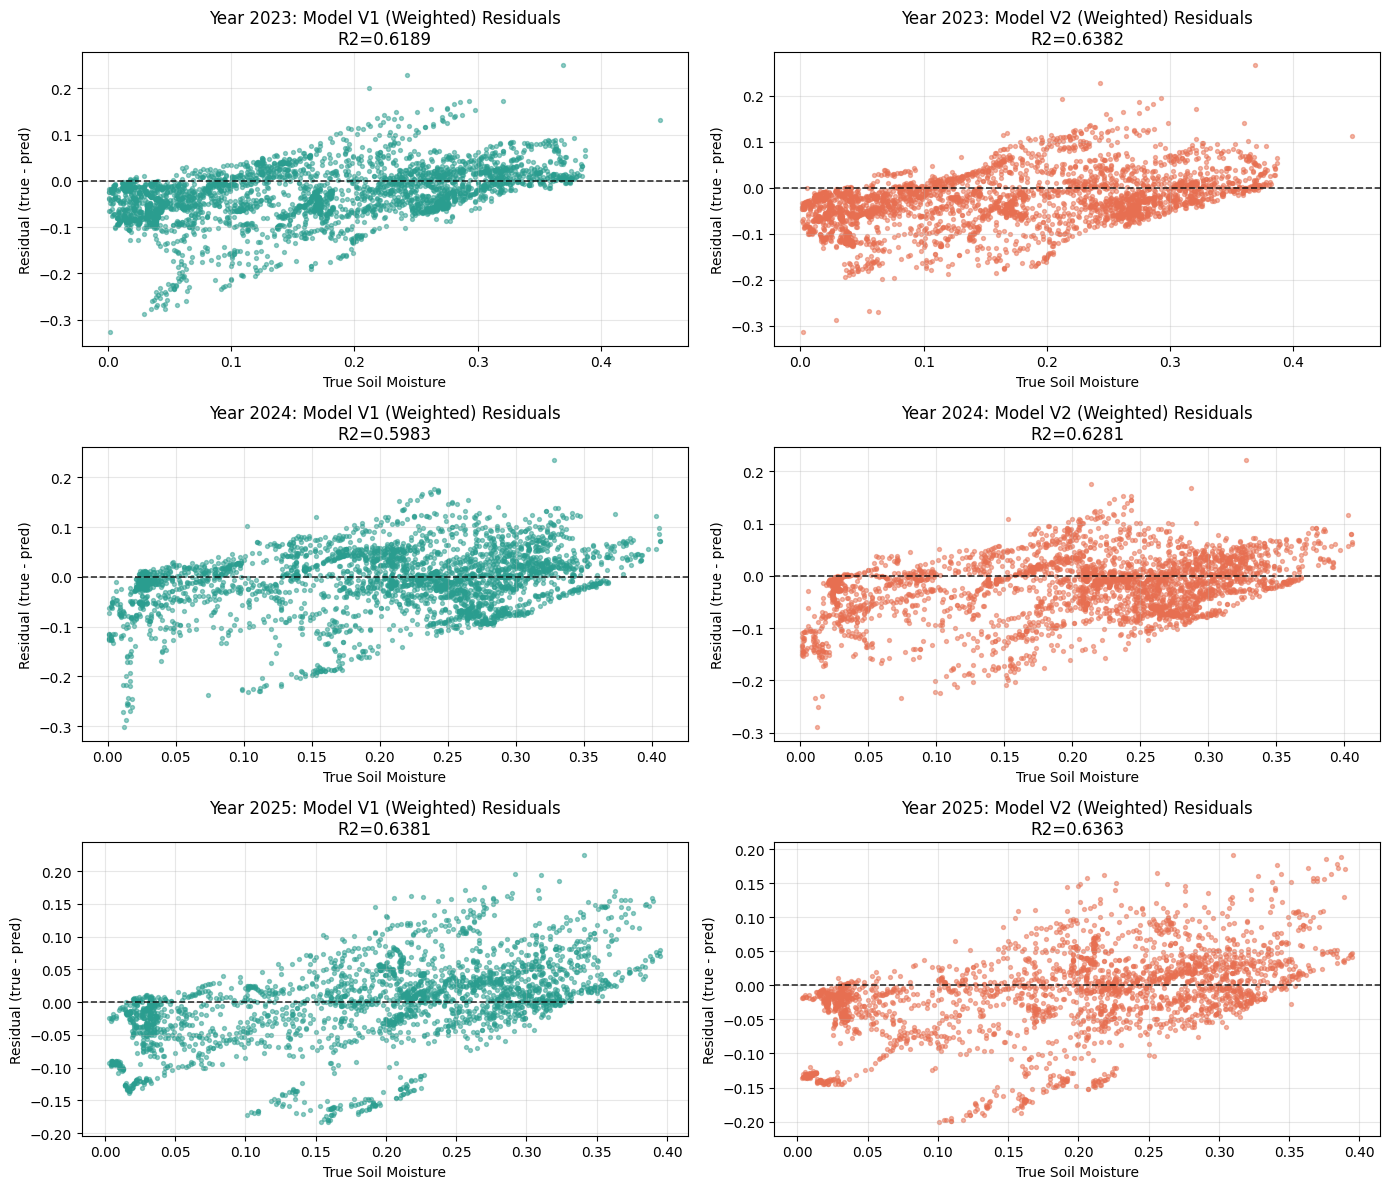

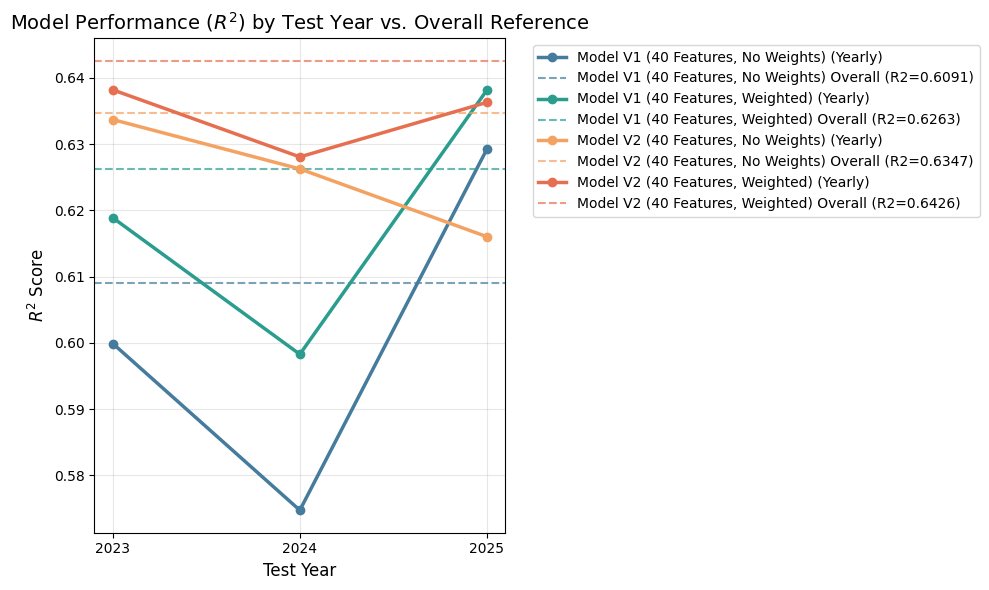

In [8]:
# Add predictions to test_df for slicing
test_df["pred_v1_no_w"] = pred_v1_no_w
test_df["pred_v1_w"] = pred_v1_w
test_df["pred_v2_no_w"] = pred_v2_no_w
test_df["pred_v2_w"] = pred_v2_w

test_years = sorted(test_df["year"].unique())
yearly_metrics_list = []

for yr in test_years:
    df_yr = test_df[test_df["year"] == yr].reset_index(drop=True)
    y_test_yr = np.asarray(df_yr[TARGET_COL]).ravel()
    
    # 1. Model V1 No Weights
    m_v1_now = compute_metrics(y_test_yr, df_yr["pred_v1_no_w"])
    m_v1_now["Year"] = int(yr)
    m_v1_now["Configuration"] = "Model V1 (40 Features, No Weights)"
    
    # 2. Model V1 Weighted
    m_v1_w = compute_metrics(y_test_yr, df_yr["pred_v1_w"])
    m_v1_w["Year"] = int(yr)
    m_v1_w["Configuration"] = "Model V1 (40 Features, Weighted)"
    
    # 3. Model V2 No Weights
    m_v2_now = compute_metrics(y_test_yr, df_yr["pred_v2_no_w"])
    m_v2_now["Year"] = int(yr)
    m_v2_now["Configuration"] = "Model V2 (40 Features, No Weights)"
    
    # 4. Model V2 Weighted
    m_v2_w = compute_metrics(y_test_yr, df_yr["pred_v2_w"])
    m_v2_w["Year"] = int(yr)
    m_v2_w["Configuration"] = "Model V2 (40 Features, Weighted)"
    
    yearly_metrics_list.extend([m_v1_now, m_v1_w, m_v2_now, m_v2_w])

yearly_summary_df = pd.DataFrame(yearly_metrics_list)
# Reorder columns
cols = ["Year", "Configuration", "R2", "RMSE", "ubRMSE", "Bias", "MAE", "Med|Err|", "Pearson"]
yearly_summary_df = yearly_summary_df[cols]

print("\n===== YEARLY COMPARATIVE PERFORMANCE SUMMARY =====")
for yr in test_years:
    print(f"\n--- Year: {int(yr)} ---")
    df_yr_m = yearly_summary_df[yearly_summary_df["Year"] == yr].drop(columns=["Year"])
    print(df_yr_m.to_string(index=False, formatters={
        'R2': '{:,.4f}'.format,
        'RMSE': '{:,.4f}'.format,
        'ubRMSE': '{:,.4f}'.format,
        'Bias': '{:+,.4f}'.format,
        'MAE': '{:,.4f}'.format,
        'Med|Err|': '{:,.4f}'.format,
        'Pearson': '{:,.4f}'.format
    }))

out_dir = PROJECT_ROOT / "notebooks/experiment/derived_8.2-eval-1.0"
yearly_summary_df.to_csv(out_dir / "metrics_by_year.csv", index=False)

# Plot residuals by year for the weighted models (V1 and V2)
fig, axes = plt.subplots(len(test_years), 2, figsize=(14, 4 * len(test_years)))

for i, yr in enumerate(test_years):
    df_yr = test_df[test_df["year"] == yr].reset_index(drop=True)
    y_test_yr = np.asarray(df_yr[TARGET_COL]).ravel()
    
    res_v1_w = y_test_yr - df_yr["pred_v1_w"]
    res_v2_w = y_test_yr - df_yr["pred_v2_w"]
    
    r2_v1 = r2_score(y_test_yr, df_yr["pred_v1_w"])
    r2_v2 = r2_score(y_test_yr, df_yr["pred_v2_w"])
    
    # Model V1 plot
    axes[i, 0].scatter(y_test_yr, res_v1_w, s=8, alpha=0.5, color='#2a9d8f')
    axes[i, 0].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    axes[i, 0].set_xlabel("True Soil Moisture")
    axes[i, 0].set_ylabel("Residual (true - pred)")
    axes[i, 0].set_title(f"Year {int(yr)}: Model V1 (Weighted) Residuals\nR2={r2_v1:.4f}")
    axes[i, 0].grid(alpha=0.3)
    
    # Model V2 plot
    axes[i, 1].scatter(y_test_yr, res_v2_w, s=8, alpha=0.5, color='#e76f51')
    axes[i, 1].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    axes[i, 1].set_xlabel("True Soil Moisture")
    axes[i, 1].set_ylabel("Residual (true - pred)")
    axes[i, 1].set_title(f"Year {int(yr)}: Model V2 (Weighted) Residuals\nR2={r2_v2:.4f}")
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(out_dir / "residuals_by_year.png")
plt.show()

# Plot R2 comparison by year including overall R2 for reference
overall_r2 = {
    "Model V1 (40 Features, No Weights)": metrics_v1_no_w["R2"],
    "Model V1 (40 Features, Weighted)": metrics_v1_w["R2"],
    "Model V2 (40 Features, No Weights)": metrics_v2_no_w["R2"],
    "Model V2 (40 Features, Weighted)": metrics_v2_w["R2"]
}

colors = {
    "Model V1 (40 Features, No Weights)": "#457b9d",
    "Model V1 (40 Features, Weighted)": "#2a9d8f",
    "Model V2 (40 Features, No Weights)": "#f4a261",
    "Model V2 (40 Features, Weighted)": "#e76f51"
}

plt.figure(figsize=(10, 6))

for config in overall_r2.keys():
    df_config = yearly_summary_df[yearly_summary_df["Configuration"] == config]
    years_plot = df_config["Year"].values
    r2_plot = df_config["R2"].values
    
    # Plot yearly trend
    plt.plot(years_plot, r2_plot, marker='o', linewidth=2.5, color=colors[config], label=f"{config} (Yearly)")
    
    # Plot overall R2 reference line
    plt.axhline(overall_r2[config], linestyle='--', color=colors[config], alpha=0.7, 
                label=f"{config} Overall (R2={overall_r2[config]:.4f})")

plt.xticks(test_years, [str(int(y)) for y in test_years])
plt.xlabel("Test Year", fontsize=12)
plt.ylabel("$R^2$ Score", fontsize=12)
plt.title("Model Performance ($R^2$) by Test Year vs. Overall Reference", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(out_dir / "r2_by_year.png", dpi=300)
plt.show()

